In [38]:
import tensorflow as tf
import numpy as np

In [49]:
def categorize_labels(label: float) -> float:
    if label < 0.5:
        return 0.0
    
    return 1.0

In [50]:
data = np.loadtxt('stock_sma_3_3_curated.csv', delimiter=',')
data = data.T
np.random.shuffle(data)
data = data.T

In [62]:
X = data[0:504,:]
raw_Y = np.array(data[-1:,:])
Y = (tf.keras.utils.to_categorical(np.vectorize(categorize_labels)(raw_Y), 2)).T

In [63]:
Y.shape = (Y.shape[0], Y.shape[1])
print(X.shape)
print(Y.shape)

(504, 99451)
(2, 99451)


In [43]:
print("Very Bear:", np.count_nonzero(Y[0]))
print("Bear:", np.count_nonzero(Y[1]))
print("Neutral:", np.count_nonzero(Y[2]))
print("Bull:", np.count_nonzero(Y[3]))
print("Very Bull:", np.count_nonzero(Y[4]))

Very Bear: 4068
Bear: 10804
Neutral: 7935
Bull: 8419
Very Bull: 9708


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(504, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-8), input_shape=(504,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(504, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-8)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(504, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-8)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 504)            │       254,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 504)            │         2,016 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 504)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 504)            │       254,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 504)            │         2,016 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 504)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 504)            │       254,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 504)            │         2,016 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 504)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │         2,525 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 772,133 (2.95 MB)

 Trainable params: 769,109 (2.93 MB)

 Non-trainable params: 3,024 (11.81 KB)

In [64]:
train_size = int(data.shape[1] * 0.8)

X_train = X[:,:train_size].T
Y_train = Y[:,:train_size].T

X_val = X[:,train_size:].T
Y_val = Y[:,train_size:].T

print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)

(79560, 504)
(79560, 2)
(19891, 504)
(19891, 2)


In [22]:
model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=30,
                  verbose=1,
                  shuffle=True)

Epoch 1/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6072 - loss: 0.9350 - val_accuracy: 0.6869 - val_loss: 0.7628
Epoch 2/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6587 - loss: 0.8017 - val_accuracy: 0.6575 - val_loss: 0.7984
Epoch 3/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6681 - loss: 0.7787 - val_accuracy: 0.6884 - val_loss: 0.7404
Epoch 4/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6766 - loss: 0.7672 - val_accuracy: 0.6852 - val_loss: 0.7390
Epoch 5/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6794 - loss: 0.7588 - val_accuracy: 0.7141 - val_loss: 0.6971
Epoch 6/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6782 - loss: 0.7577 - val_accuracy: 0.6935 - val_loss: 0.7133
Epoch 7/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6844 - loss: 0.7503 - val_accuracy: 0.6864 - val_loss: 0.7470
Epoch 8/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6846 - loss: 0.7482 - 

In [55]:
import matplotlib.pyplot as plt

def plot_acc_and_loss(history, title):
    plt.title("Model and Validation Accuracy for " + title)
    xs = list(range(1, len(history.history['accuracy']) + 1))
    plt.plot(xs, history.history['accuracy'], label="Model Accuracy", color="Red")
    plt.plot(xs, history.history['val_accuracy'], label="Validation Accuracy", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.title("Model and Validation Loss for " + title)
    xs = list(range(1, len(history.history['val_loss']) + 1))
    plt.plot(xs, history.history['loss'], label="Model loss", color="Red")
    plt.plot(xs, history.history['val_loss'], label="Validation loss", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.legend()
    plt.show()

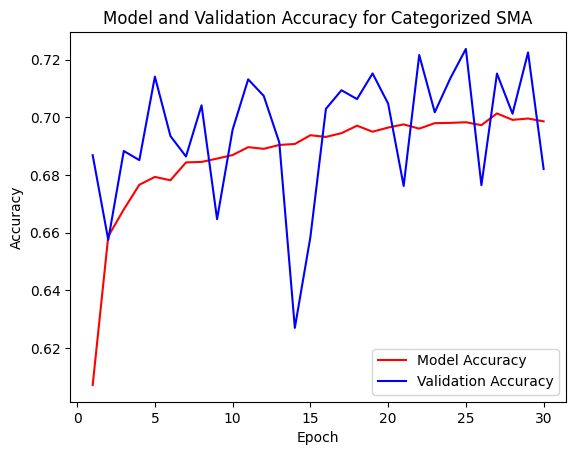

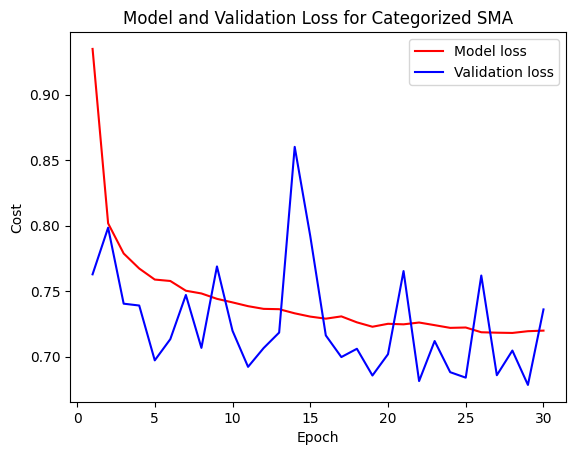

In [56]:
plot_acc_and_loss(model.history, "Categorized SMA")

In [57]:
print("Prediction:", model(X_val[5:10]))
print("Label:", Y_val[5:10])

Prediction: tf.Tensor(
[[9.22460318e-01 7.65871182e-02 9.51575348e-04 1.01716807e-06
  2.38588233e-10]
 [1.48296792e-11 8.76648016e-07 1.19008811e-03 3.95471267e-02
  9.59261894e-01]
 [3.36369991e-01 5.35275877e-01 1.26582950e-01 1.76639692e-03
  4.83460326e-06]
 [2.22059204e-10 4.43460931e-06 5.74024813e-03 1.09171115e-01
  8.85084212e-01]
 [4.24296767e-01 5.16467512e-01 5.87570854e-02 4.77742025e-04
  8.88015450e-07]], shape=(5, 5), dtype=float32)
Label: [[0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]]


In [65]:
modelThin = tf.keras.Sequential([
    tf.keras.layers.Dense(504, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-8), input_shape=(504,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(2, activation='softmax'),
])

modelThin.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelThin.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 504)            │       254,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 504)            │         2,016 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 504)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 2)              │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,546 (1006.04 KB)

 Trainable params: 256,538 (1002.10 KB)

 Non-trainable params: 1,008 (3.94 KB)

In [66]:
modelThin.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=30,
                  verbose=1,
                  shuffle=True)

Epoch 1/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8890 - loss: 0.2662 - val_accuracy: 0.8943 - val_loss: 0.2497
Epoch 2/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9042 - loss: 0.2272 - val_accuracy: 0.9124 - val_loss: 0.2152
Epoch 3/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9062 - loss: 0.2216 - val_accuracy: 0.9061 - val_loss: 0.2268
Epoch 4/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9083 - loss: 0.2158 - val_accuracy: 0.9134 - val_loss: 0.2093
Epoch 5/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9110 - loss: 0.2120 - val_accuracy: 0.8988 - val_loss: 0.2407
Epoch 6/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9116 - loss: 0.2105 - val_accuracy: 0.9168 - val_loss: 0.2025
Epoch 7/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9135 - loss: 0.2071 - val_accuracy: 0.9128 - val_loss: 0.2122
Epoch 8/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9136 - loss: 0.2073 - 

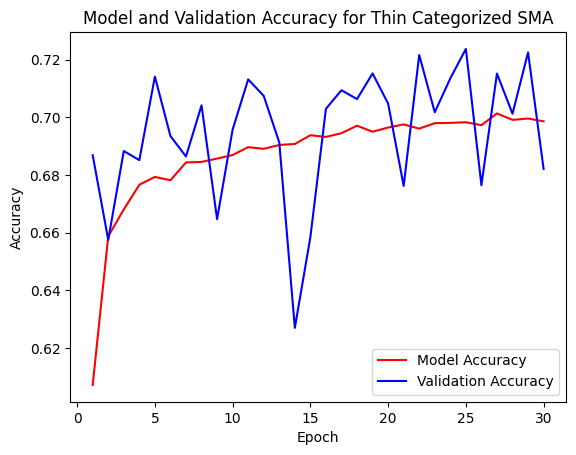

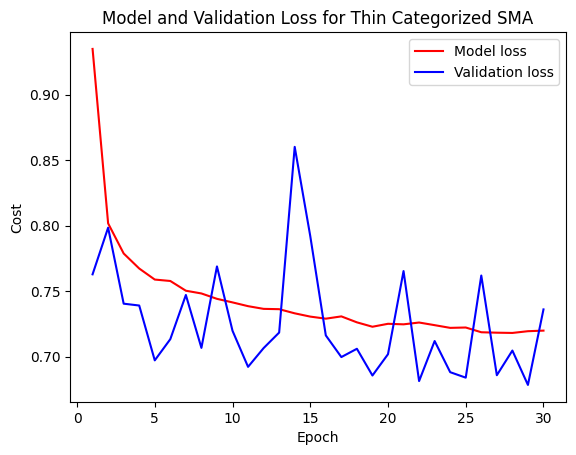

In [67]:
plot_acc_and_loss(model.history, "Thin Categorized SMA")